# **Face & Object Recognition**

## Step 1: Install & Import Libraries

In [1]:
!pip install tensorflow opencv-python-headless matplotlib numpy pillow -q

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input, decode_predictions
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from PIL import Image
from google.colab import files
import io, os, zipfile

print('TF:', tf.__version__, '| OpenCV:', cv2.__version__)

TF: 2.20.0 | OpenCV: 4.13.0


## Part A: Face Detection with Haar Cascades

Haar Cascade classifiers are classical (non-deep-learning) detectors that slide a window across the image, looking for patterns in pixel intensity differences.

### Step 2: Upload a Face Image

Upload an image containing one or more faces:


Saving people.jpeg to people.jpeg


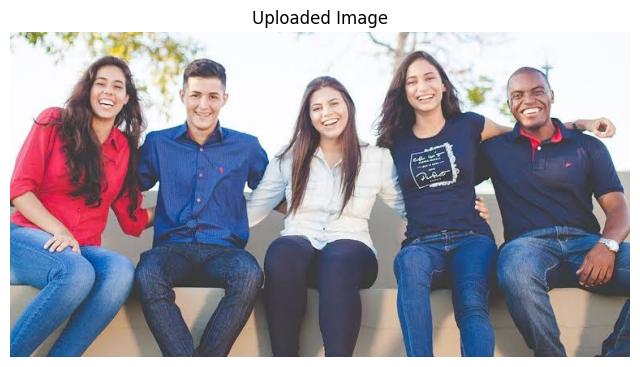

In [3]:
print('Upload an image containing one or more faces:')
uploaded = files.upload()

fname = list(uploaded.keys())[0]
img = cv2.imdecode(np.frombuffer(uploaded[fname], np.uint8), cv2.IMREAD_COLOR)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,6))
plt.imshow(img_rgb)
plt.title('Uploaded Image', fontsize=12)
plt.axis('off')
plt.show()

### Step 3: Detect Faces

Faces detected: 7


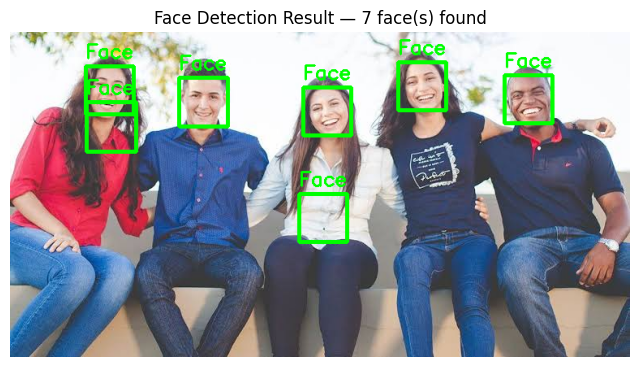

In [4]:
# Download Haar cascade XML file
import urllib.request
cascade_url = 'https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml'
urllib.request.urlretrieve(cascade_url, 'haarcascade_frontalface_default.xml')

face_cascade = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30,30))

print(f'Faces detected: {len(faces)}')

# Draw bounding boxes
result = img_rgb.copy()
for (x, y, w, h) in faces:
    cv2.rectangle(result, (x, y), (x+w, y+h), (0, 255, 0), 3)
    cv2.putText(result, 'Face', (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,255,0), 2)

plt.figure(figsize=(8,6))
plt.imshow(result)
plt.title(f'Face Detection Result — {len(faces)} face(s) found', fontsize=12)
plt.axis('off')
plt.show()

## Part B: Object Recognition with MobileNetV2 (ImageNet)


### Step 4: Upload an Object Image

Upload an image of any object you want to recognise:


Saving people.jpeg to people (1).jpeg


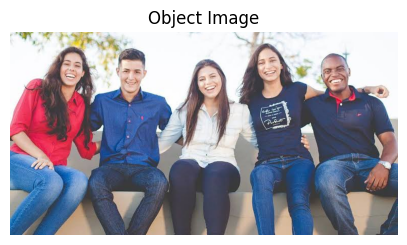

In [5]:
print('Upload an image of any object you want to recognise:')
up_obj = files.upload()
obj_fname = list(up_obj.keys())[0]
obj_img = Image.open(io.BytesIO(up_obj[obj_fname])).convert('RGB')

plt.figure(figsize=(5,5))
plt.imshow(obj_img)
plt.title('Object Image', fontsize=12)
plt.axis('off')
plt.show()

14536120/14536120 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Top-5 Predictions:
Rank Label                         Confidence
---------------------------------------------
1    jean                          87.98%
2    sweatshirt                    1.06%
3    jersey                        0.94%
4    cowboy_boot                   0.80%
5    maillot                       0.50%


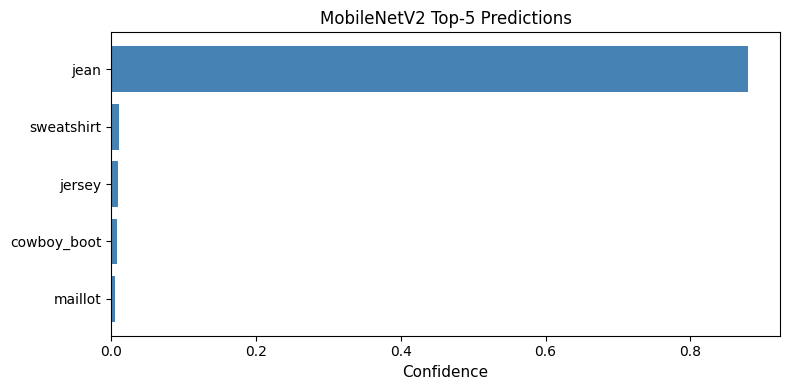

In [6]:
# Load pretrained MobileNetV2
mobilenet = MobileNetV2(weights='imagenet', input_shape=(224,224,3))

# Preprocess the object image
img_resized = obj_img.resize((224,224))
arr = np.expand_dims(np.array(img_resized, dtype='float32'), axis=0)
arr = preprocess_input(arr)

# Predict
preds = mobilenet.predict(arr, verbose=0)
top_preds = decode_predictions(preds, top=5)[0]

print('Top-5 Predictions:')
print(f'{"Rank":<5}{"Label":<30}{"Confidence"}')
print('-' * 45)
for i, (wn_id, label, prob) in enumerate(top_preds, 1):
    print(f'{i:<5}{label:<30}{prob*100:.2f}%')

# Bar chart
labels = [p[1] for p in top_preds]
confs  = [p[2] for p in top_preds]
plt.figure(figsize=(8,4))
bars = plt.barh(labels[::-1], confs[::-1], color='steelblue')
plt.xlabel('Confidence', fontsize=11)
plt.title('MobileNetV2 Top-5 Predictions', fontsize=12)
plt.tight_layout()
plt.show()